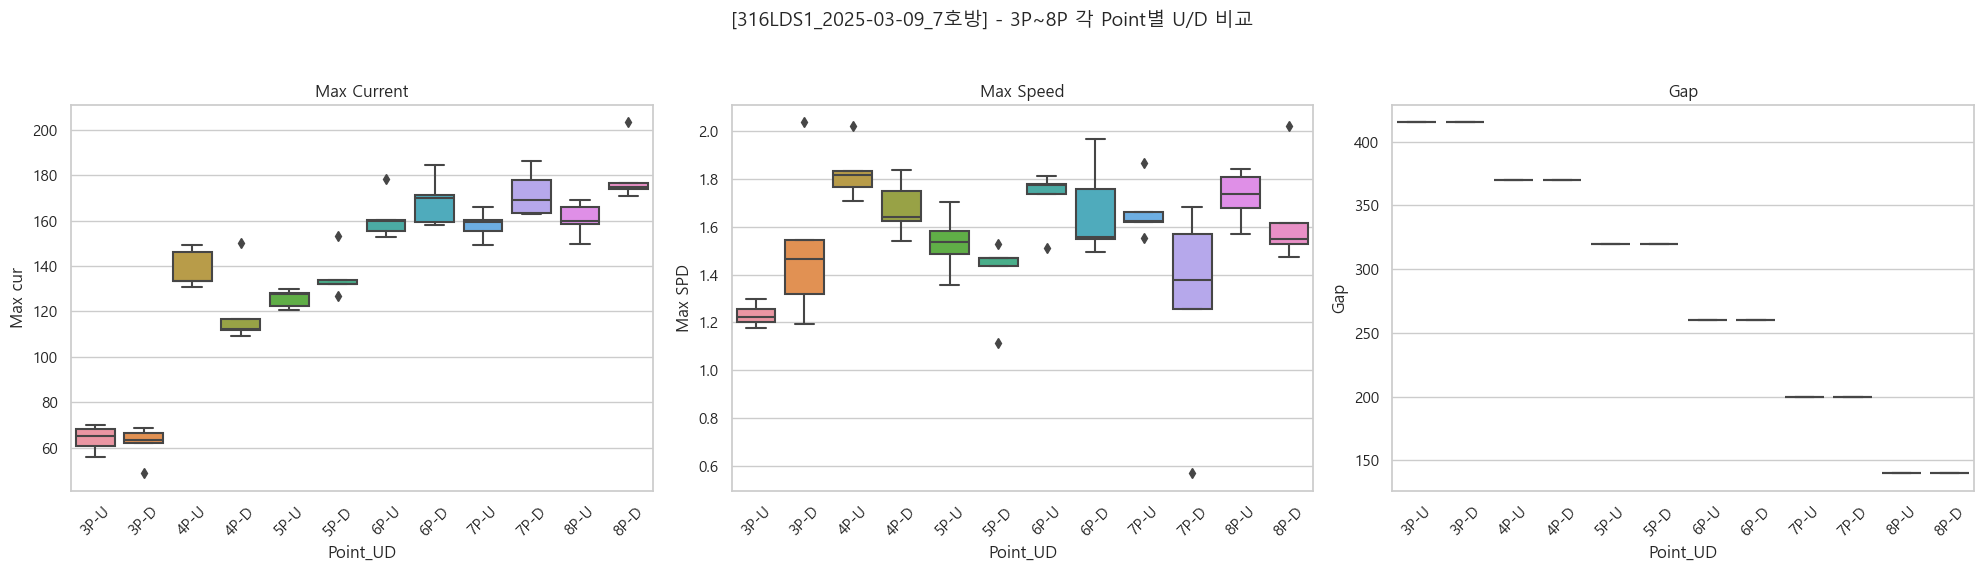

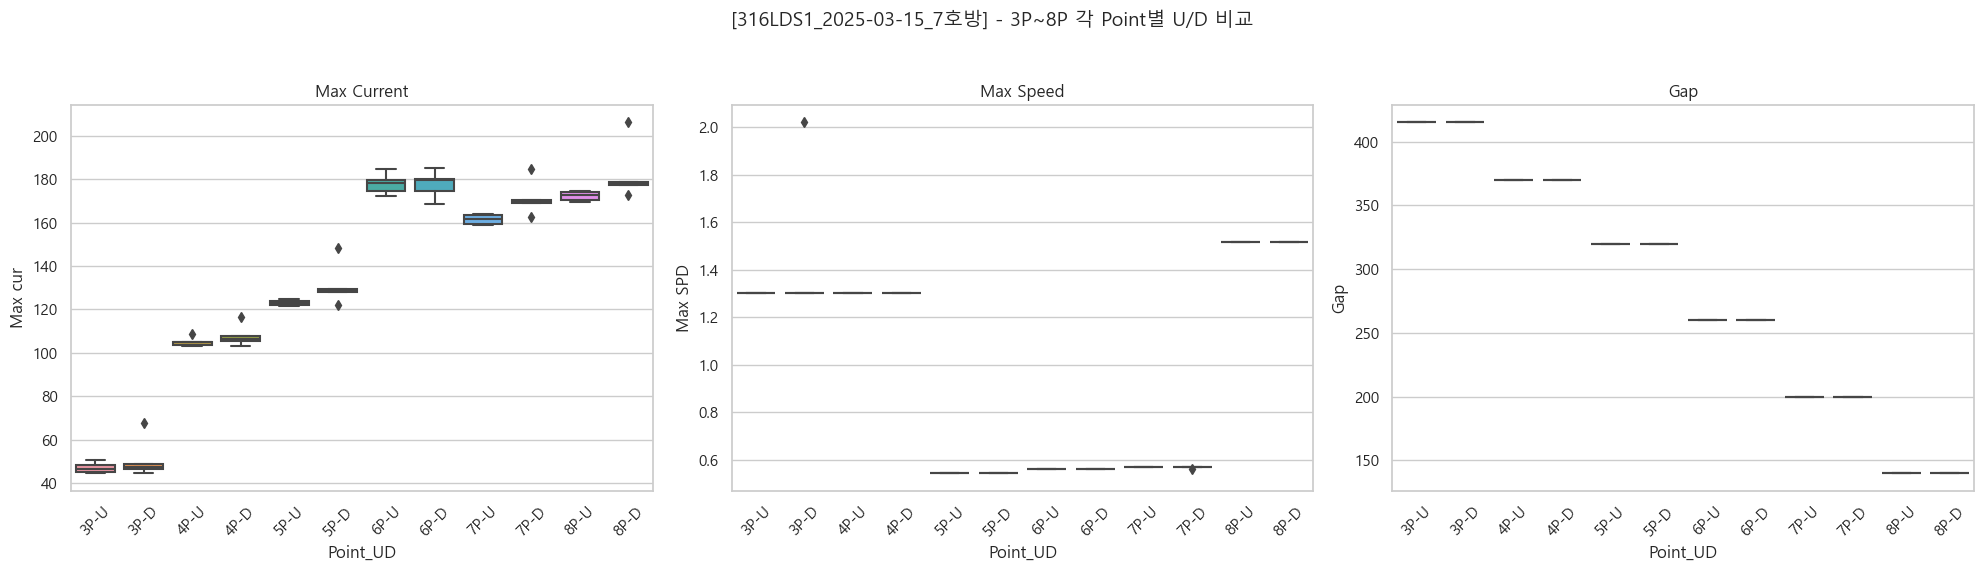

In [26]:
#가열호수 추가 코드
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📌 한글 폰트 설정 (Windows 환경 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 📁 엑셀 파일 경로 설정
file_path = os.path.join("data2", "250617_Data_form2.xlsx")  # 파일명은 실제와 맞게 수정하세요

# 📥 데이터 불러오기
df = pd.read_excel(file_path,sheet_name="Sheet3")

# 🔧 구분 열 생성: 사내강종 + 시작일 + 가열호수
df['구분'] = (
    df['사내강종'].astype(str) + "_" +
    df['시작일'].astype(str) + "_" +
    df['가열호수'].astype(str)
)

# 🔄 3P~8P 데이터를 long-form으로 변환
melted = pd.DataFrame()
for p in range(3, 9):
    temp = df[['구분', 'UD', f'Max cur_{p}P', f'Max SPD_{p}P', f'Gap_{p}P']].copy()
    temp = temp.rename(columns={
        f'Max cur_{p}P': 'Max cur',
        f'Max SPD_{p}P': 'Max SPD',
        f'Gap_{p}P': 'Gap'
    })
    temp['Point'] = f'{p}P'
    temp['Point_UD'] = f'{p}P-' + temp['UD']
    melted = pd.concat([melted, temp], ignore_index=True)

# 🎯 구분별로 3개의 Boxplot 출력 (x축: Point_UD)
for key in melted['구분'].unique():
    subset = melted[melted['구분'] == key]

    # 전체 데이터가 비어있으면 skip
    if subset[['Max cur', 'Max SPD', 'Gap']].dropna(how='all').empty:
        continue

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
    fig.suptitle(f"[{key}] - 3P~8P 각 Point별 U/D 비교", fontsize=14)

    # Max cur boxplot
    if not subset['Max cur'].dropna().empty:
        sns.boxplot(data=subset, x='Point_UD', y='Max cur', ax=axes[0])
        axes[0].set_title('Max Current')
        axes[0].set_ylabel('Max cur')
        axes[0].tick_params(axis='x', rotation=45)

    # Max SPD boxplot
    if not subset['Max SPD'].dropna().empty:
        sns.boxplot(data=subset, x='Point_UD', y='Max SPD', ax=axes[1])
        axes[1].set_title('Max Speed')
        axes[1].set_ylabel('Max SPD')
        axes[1].tick_params(axis='x', rotation=45)

    # Gap boxplot
    if not subset['Gap'].dropna().empty:
        sns.boxplot(data=subset, x='Point_UD', y='Gap', ax=axes[2])
        axes[2].set_title('Gap')
        axes[2].set_ylabel('Gap')
        axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


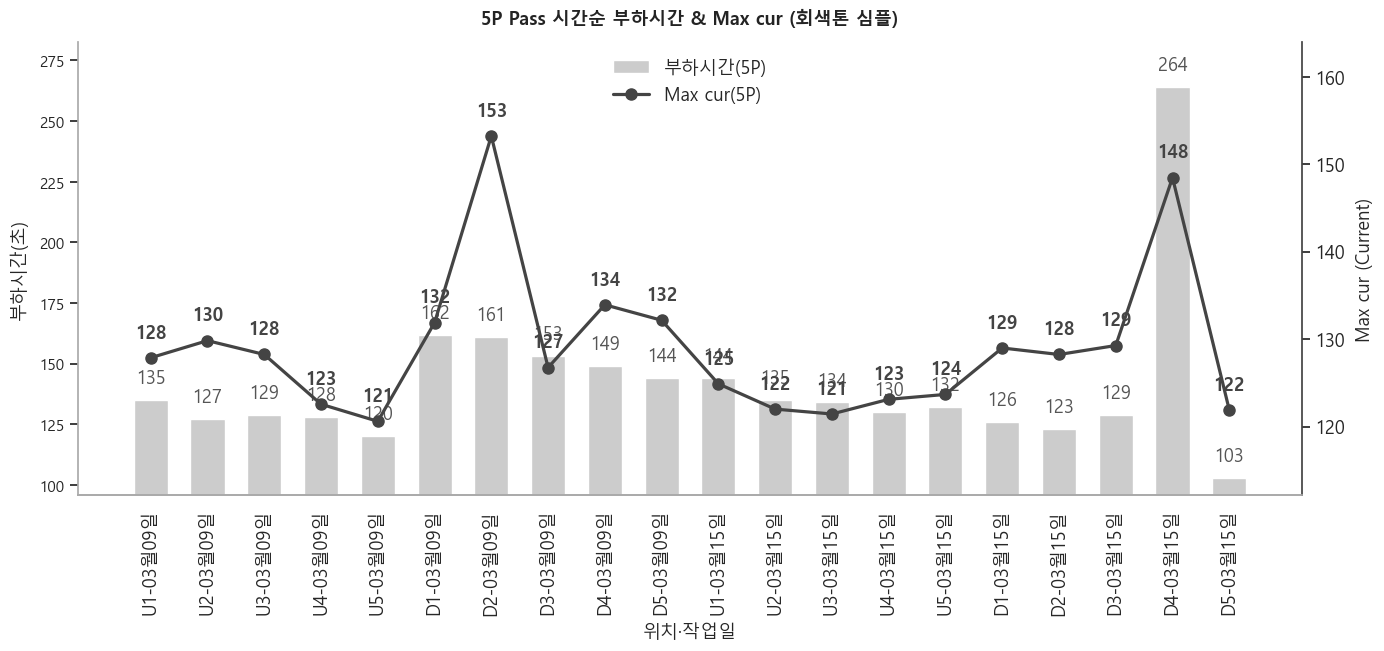

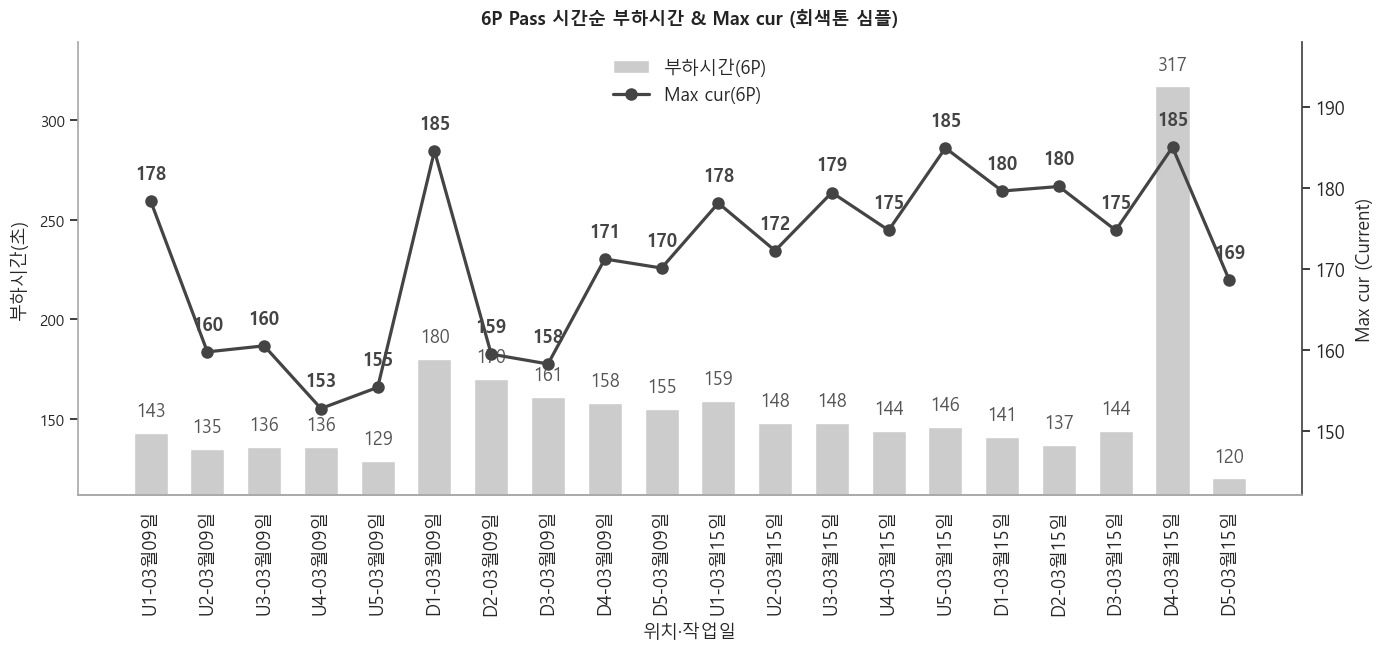

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 글꼴/글자크기 통일
FONT_SIZE = 13

sns.set_theme(style="white", font="Malgun Gothic", rc={"axes.unicode_minus": False})
sns.set_context("notebook", font_scale=1.0)

file_path = os.path.join("data2", "250617_Data_form2.xlsx")
df = pd.read_excel(file_path, sheet_name="Sheet3")

df['압연일시'] = pd.to_datetime(
    df['기준일자'].astype(str) + ' ' + df['시작시간'].astype(str), errors='coerce')
df['x_label'] = (
    df['위치구분'].astype(str)
    + '-' +
    df['기준일자'].astype(str).str[5:].str.replace('-', '월') + '일'
)

pass_pick = [6]

for p in pass_pick:
    cur_col = f"Max cur_{p}P"
    load_col = f"Door_open-{p}P_Max부하시간"

    df_plot = df[['압연일시', 'x_label', cur_col, load_col]].dropna()
    df_plot = df_plot.sort_values('압연일시')
    x = df_plot['x_label']
    y1 = df_plot[load_col]
    y2 = df_plot[cur_col]

    if len(df_plot) == 0:
        print(f"{p}P: 표시할 데이터가 없습니다.")
        continue

    plt.figure(figsize=(max(14, len(df_plot)//2.5), 6))
    ax1 = plt.gca()

    # 막대그래프 (연회색)
    bar_color = '#cccccc'
    bars = ax1.bar(
        x, y1, color=bar_color, width=0.6,
        zorder=2, label=f'부하시간({p}P)'
    )
    for i, v in enumerate(y1):
        ax1.text(i, v + (max(y1)*0.02), f'{round(v)}', ha='center', va='bottom',
                 fontsize=FONT_SIZE, color="#555555")

    ax1.set_ylabel(f'부하시간(초)', fontsize=FONT_SIZE, labelpad=8)
    ax1.set_xlabel('위치·작업일', fontsize=FONT_SIZE, labelpad=6)
    ax1.tick_params(axis='x', rotation=90, labelsize=FONT_SIZE, pad=4)
    ax1.set_ylim([min(y1)*0.93, max(y1)*1.07])
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#aaaaaa')
    ax1.spines['bottom'].set_color('#aaaaaa')

    # 꺾은선그래프 (진회색)
    line_color = '#444444'
    ax2 = ax1.twinx()
    ax2.plot(
        x, y2, color=line_color, marker='o', linewidth=2.3, markersize=8,
        label=f'Max cur({p}P)', zorder=10
    )
    for i, v in enumerate(y2):
        ax2.text(i, v + (max(y2)*0.012), f'{round(v)}', color=line_color,
                 ha='center', va='bottom', fontsize=FONT_SIZE, fontweight='bold')
    ax2.set_ylabel(f'Max cur (Current)', fontsize=FONT_SIZE, labelpad=8)
    ax2.set_ylim([min(y2)*0.93, max(y2)*1.07])
    ax2.tick_params(axis='y', labelsize=FONT_SIZE)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_color('#444444')
    ax2.spines['left'].set_visible(False)
    ax2.spines['bottom'].set_color('#aaaaaa')

    # 격자, 배경 등 모두 OFF
    ax1.grid(False)
    ax2.grid(False)

    # 범례: 폰트 동일, 프레임 없이, 딱 2개만
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc='upper center', fontsize=FONT_SIZE, frameon=False)

    plt.title(
        f"{p}P Pass 시간순 부하시간 & Max cur (회색톤 심플)",
        fontsize=FONT_SIZE, fontweight="bold", color="#232323", pad=13
    )
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.subplots_adjust(bottom=0.16)
    plt.show()


c:\python_study\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\python_study\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\python_study\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\python_study\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with

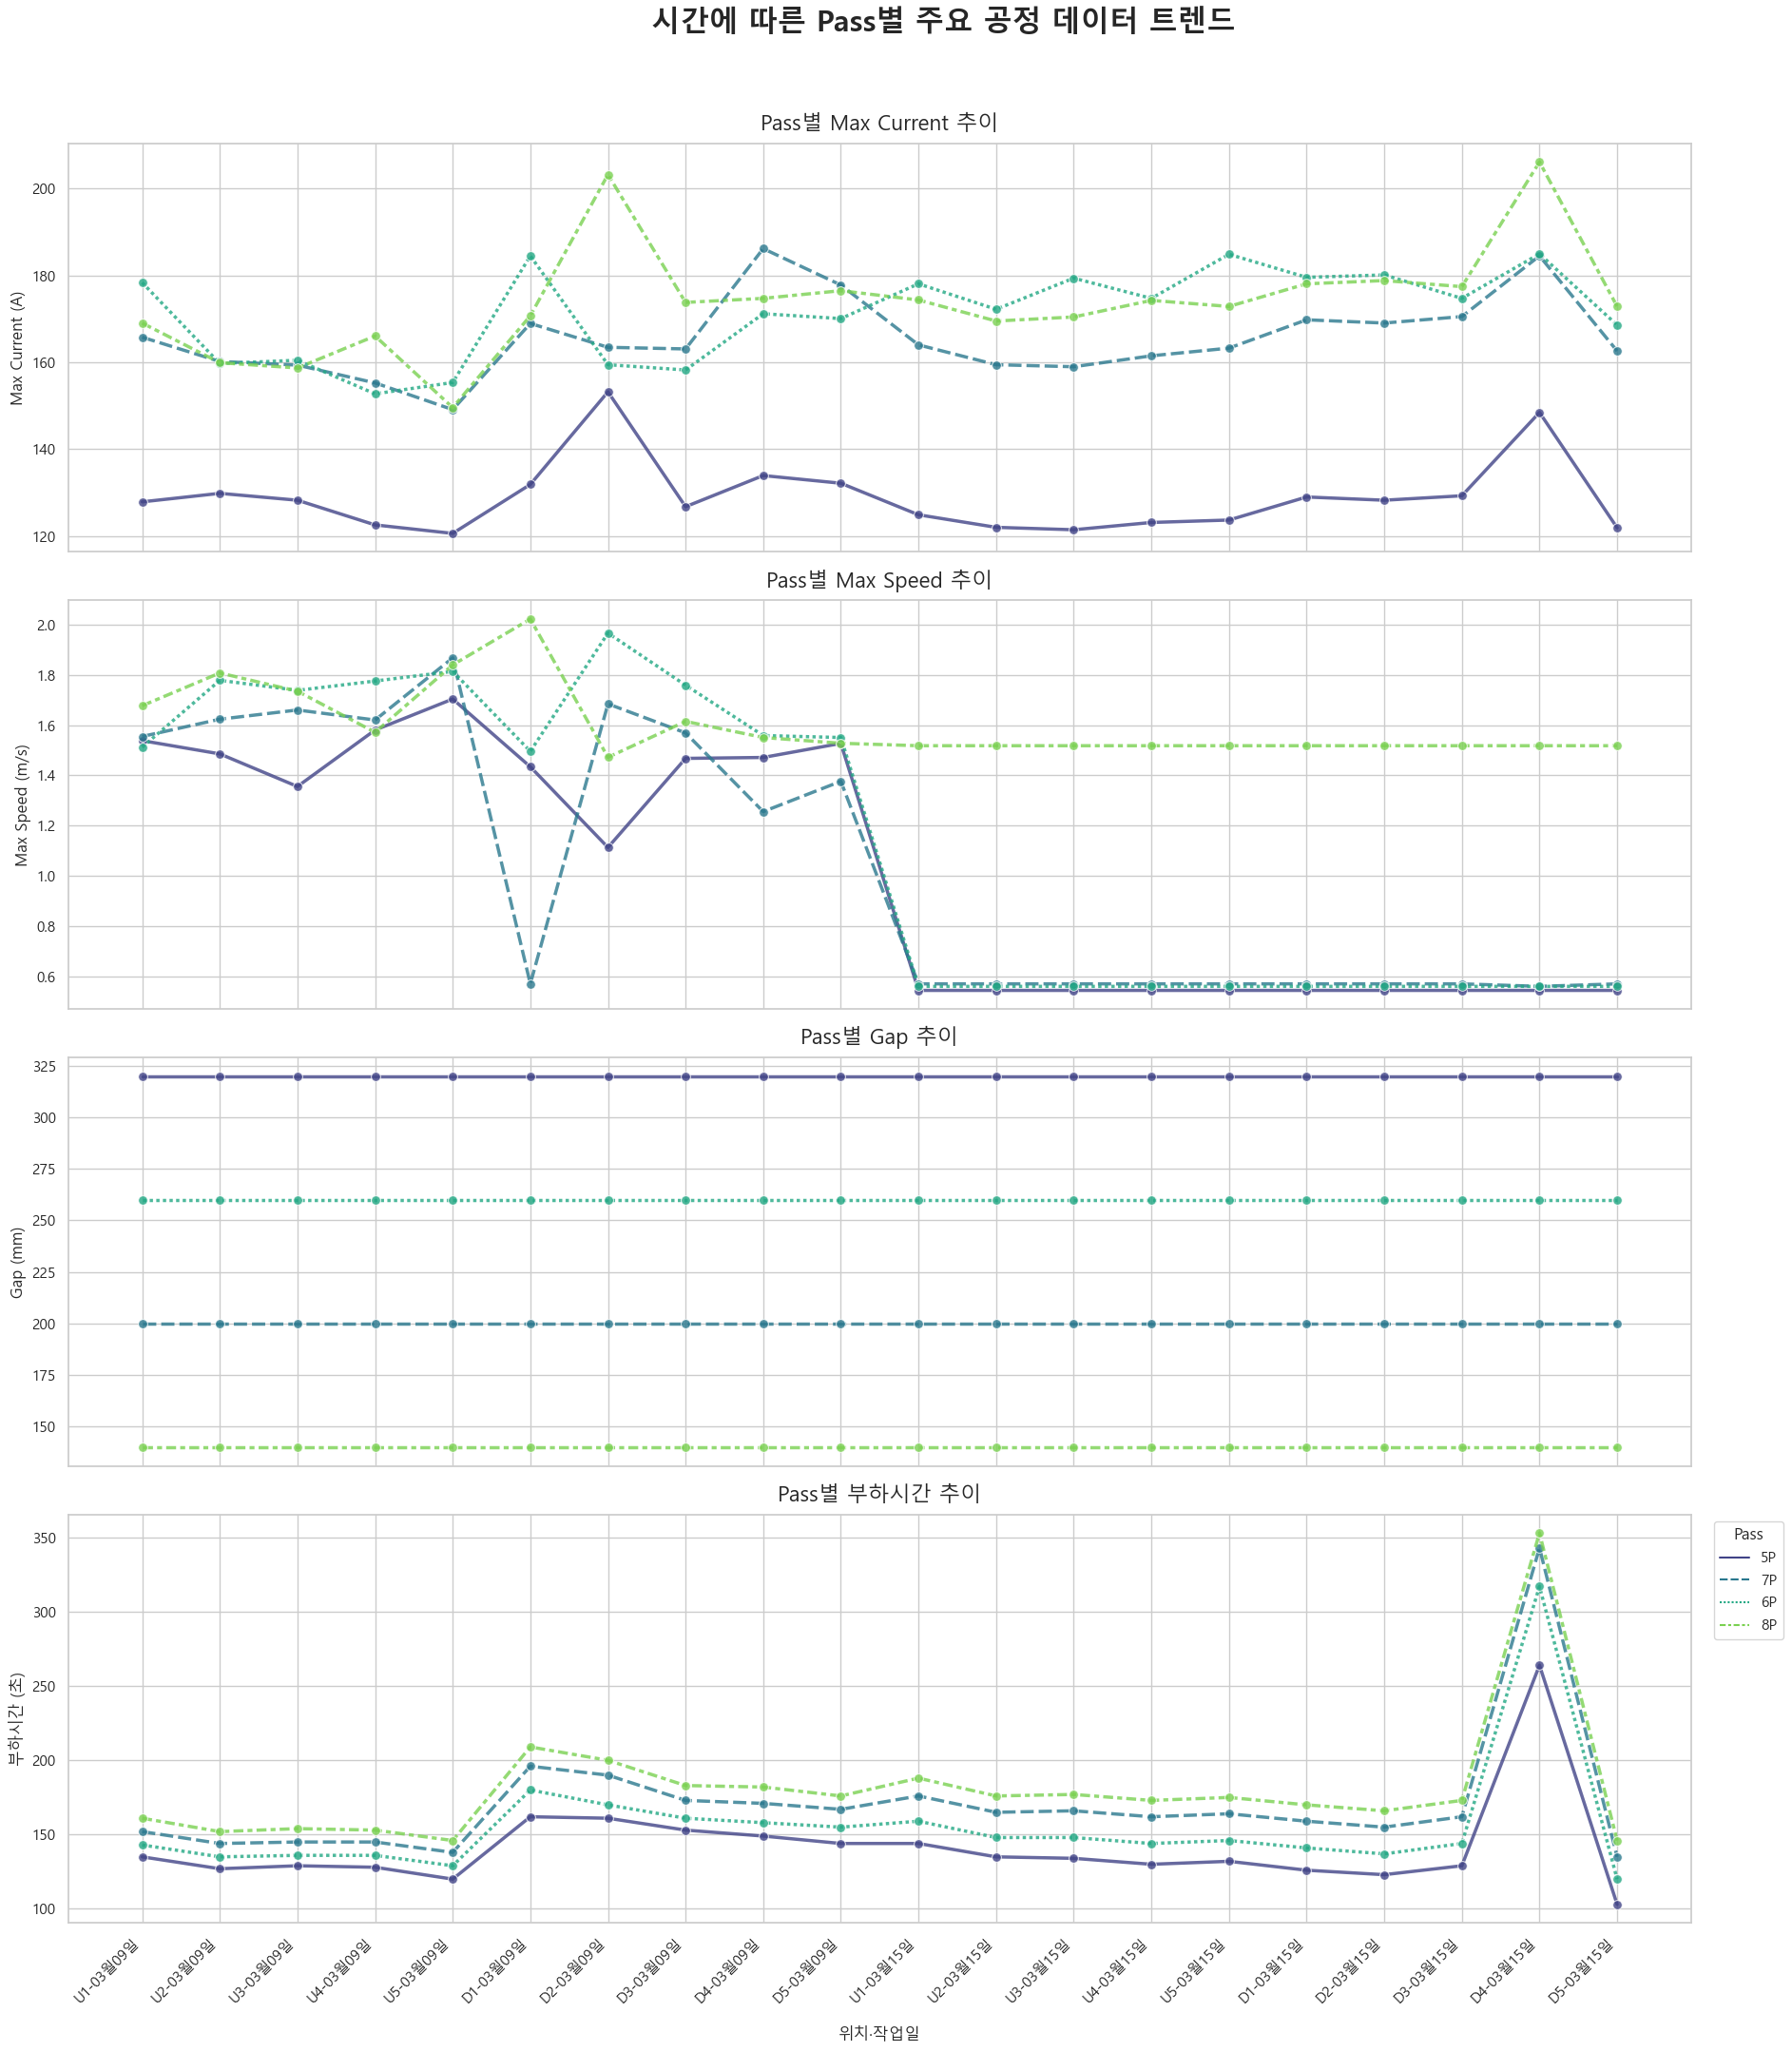

In [4]:
#r"C:\python_study\01.엑셀자동화기초\data2\250617_Data_form2.xlsx"
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np # numpy 라이브러리 추가

# ====================================================
# ❶ 기본 설정 및 Pass 선택
# ====================================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

file_path = r"C:\python_study\01.엑셀자동화기초\data2\250617_Data_form2.xlsx"

pass_selection = [5, 6, 7, 8]

# ====================================================
# ❷ 데이터 불러오기 및 전처리
# ====================================================
if not pass_selection:
    print("오류: 선택된 Pass가 없습니다.")
    print("pass_selection = [...] 리스트에 원하는 Pass 번호를 1개 이상 추가해주세요.")
    exit()

try:
    df = pd.read_excel(file_path, sheet_name="Sheet3")
except FileNotFoundError:
    print(f"오류: '{file_path}' 파일을 찾을 수 없습니다.")
    print("스크립트를 실행하기 전에 파일이 올바른 위치에 있는지 확인해주세요.")
    exit()

df['압연일시'] = pd.to_datetime(
    df['기준일자'].astype(str) + ' ' + df['시작시간'].astype(str), errors='coerce'
)
df['x_label'] = (
    df['위치구분'].astype(str)
    + '-' +
    df['기준일자'].astype(str).str[5:].str.replace('-', '월') + '일'
)

all_melted = []
for p in pass_selection:
    subset = df[[
        '압연일시', 'x_label',
        f'Max cur_{p}P', f'Max SPD_{p}P', f'Gap_{p}P', f'Door_open-{p}P_Max부하시간'
    ]].copy()
    
    subset.rename(columns={
        f'Max cur_{p}P': 'Max cur',
        f'Max SPD_{p}P': 'Max SPD',
        f'Gap_{p}P': 'Gap',
        f'Door_open-{p}P_Max부하시간': '부하시간'
    }, inplace=True)
    
    subset['Pass'] = f'{p}P'
    all_melted.append(subset)

melted_df = pd.concat(all_melted, ignore_index=True)

# ★★★ 수정된 부분 ★★★
# 데이터 내의 무한대(inf) 값을 결측치(NaN)으로 변경하여 경고 메시지 발생 방지
melted_df.replace([np.inf, -np.inf], np.nan, inplace=True)

melted_df.dropna(subset=['압연일시'], inplace=True) 
melted_df.sort_values(by='압연일시', inplace=True)


# ====================================================
# ❸ 대시보드 시각화
# ====================================================
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(20, 22), sharex=True)
fig.suptitle("시간에 따른 Pass별 주요 공정 데이터 트렌드", fontsize=22, fontweight='bold')

metrics = ['Max cur', 'Max SPD', 'Gap', '부하시간']
titles = [
    'Pass별 Max Current 추이',
    'Pass별 Max Speed 추이',
    'Pass별 Gap 추이',
    'Pass별 부하시간 추이'
]
ylabels = ['Max Current (A)', 'Max Speed (m/s)', 'Gap (mm)', '부하시간 (초)']

palette = sns.color_palette("viridis", n_colors=len(pass_selection))

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    sns.lineplot(
        data=melted_df,
        x='x_label',
        y=metric,
        hue='Pass',
        style='Pass',
        ax=ax,
        palette=palette,
        marker='o',
        markersize=7,
        linewidth=2.5,
        alpha=0.8
    )
    
    ax.set_title(titles[i], fontsize=16, pad=10)
    ax.set_ylabel(ylabels[i], fontsize=12)
    ax.tick_params(axis='y', labelsize=11)
    
    if i < len(metrics) - 1:
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    else:
        ax.legend(title='Pass', bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=11, title_fontsize=12)

# ====================================================
# ❹ 최종 꾸미기 및 출력
# ====================================================
axes[-1].set_xlabel("위치·작업일", fontsize=12, labelpad=15)
plt.xticks(rotation=45, ha='right', fontsize=11)

plt.tight_layout(rect=[0, 0, 0.95, 0.96])

plt.savefig("Selected_Process_Trend_Dashboard.png", dpi=150)
plt.show()